In [1]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt

In [2]:
from lobster import *

In [ ]:
ticker = "AMZN"
message_path  = f"data/LOBSTER_SampleFile_{ticker}_2012-06-21_5/{ticker}_2012-06-21_34200000_57600000_message_5.csv"
orderbook_path = f"data/LOBSTER_SampleFile_{ticker}_2012-06-21_5/{ticker}_2012-06-21_34200000_57600000_orderbook_5.csv"
levels=5
K=5

msg, ob, qr, df = load_lobster_data(message_path, orderbook_path, levels=levels, K=K)
#[["type", "lvl", "size", "P_1", "Q_1", "P_-1", "Q_-1", "P_2", "Q_2", "P_-2", "Q_-2", "P_3", "Q_3", "P_-3", "Q_-3", "P_4", "Q_4", "P_-4", "Q_-4", "P_5", "Q_5", "P_-5", "Q_-5"]]
df

,time,dtk,dtk_l,type,price,lvl,size,pref,P_1,Q_1,...,Q_-3,P_4,Q_4,P_-4,Q_-4,P_5,Q_5,P_-5,Q_-5,seg_id
0,34200.271740,0.271740,0.271740,L,5857400,1,40,5857350.0,5857400.0,40,...,0,5857700.0,0,5857000.0,0,5857800.0,0,5856900.0,0,1
1,34200.271740,0.000000,0.000000,L,5857000,-4,50,5857350.0,5857400.0,40,...,0,5857700.0,0,5857000.0,50,5857800.0,0,5856900.0,0,1
2,34200.271740,0.000000,0.000000,L,5857500,2,50,5857350.0,5857400.0,40,...,0,5857700.0,0,5857000.0,50,5857800.0,0,5856900.0,0,1
3,34200.271740,0.000000,0.000000,L,5856900,-5,20,5857350.0,5857400.0,40,...,0,5857700.0,0,5857000.0,50,5857800.0,0,5856900.0,20,1
4,34200.271740,0.000000,0.000000,L,5857500,2,5,5857350.0,5857400.0,40,...,0,5857700.0,0,5857000.0,50,5857800.0,0,5856900.0,20,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62420,57599.444020,0.000142,0.060813,M,5776000,-1,103,5776350.0,5776400.0,0,...,0,5776700.0,300,5776000.0,11,5776800.0,200,5775900.0,0,23173
62421,57599.444020,0.000000,0.000000,M,5776000,-1,11,5776050.0,5776100.0,0,...,0,5776400.0,0,5775700.0,0,5776500.0,0,5775600.0,0,23174
62422,57599.444020,0.000000,0.000000,L,5776100,4,48,5775750.0,5775800.0,0,...,0,5776100.0,48,5775400.0,410,5776200.0,0,5775300.0,1400,23175
62423,57599.913118,0.469098,0.000000,M,5776100,1,48,5776050.0,5776100.0,0,...,0,5776400.0,0,5775700.0,0,5776500.0,0,5775600.0,0,23176


In [4]:
table1 = make_descriptive_table(df, K=5)
table1

,#L (×10^3),#C (×10^3),#M (×10^2),AES,AIT (ms)
Level,,,,,
1,1.62,0.72,349.9,83.29,197.3
2,2.55,1.40,0.0,104.72,82.4
3,3.38,1.84,0.0,109.73,137.7
4,4.41,2.59,0.0,101.69,210.5
5,5.54,3.39,0.0,96.68,285.4


In [5]:
aes = compute_aes_by_level(df, K=5, lvl_col="lvl", size_col="size") 
df_norm = normalize_by_aes(df, aes=aes, K=5)
df_norm.head(10)

,time,dtk,dtk_l,type,price,lvl,size,pref,P_1,Q_1,...,Q_-3,P_4,Q_4,P_-4,Q_-4,P_5,Q_5,P_-5,Q_-5,seg_id
0,34200.271740,0.271740,0.271740,L,5857400,1,1,5857350.0,5857400.0,1,...,0,5857700.0,0,5857000.0,0,5857800.0,0,5856900.0,0,1
1,34200.271740,0.000000,0.000000,L,5857000,-4,1,5857350.0,5857400.0,1,...,0,5857700.0,0,5857000.0,1,5857800.0,0,5856900.0,0,1
2,34200.271740,0.000000,0.000000,L,5857500,2,1,5857350.0,5857400.0,1,...,0,5857700.0,0,5857000.0,1,5857800.0,0,5856900.0,0,1
3,34200.271740,0.000000,0.000000,L,5856900,-5,1,5857350.0,5857400.0,1,...,0,5857700.0,0,5857000.0,1,5857800.0,0,5856900.0,1,1
4,34200.271740,0.000000,0.000000,L,5857500,2,1,5857350.0,5857400.0,1,...,0,5857700.0,0,5857000.0,1,5857800.0,0,5856900.0,1,1
5,34200.271740,0.000000,0.000000,L,5857500,2,1,5857350.0,5857400.0,1,...,0,5857700.0,0,5857000.0,1,5857800.0,0,5856900.0,1,1
6,34200.271740,0.000000,0.000000,L,5857500,2,1,5857350.0,5857400.0,1,...,0,5857700.0,0,5857000.0,1,5857800.0,0,5856900.0,1,1
7,34200.271740,0.000000,0.000000,L,5857800,5,1,5857350.0,5857400.0,1,...,0,5857700.0,0,5857000.0,1,5857800.0,1,5856900.0,1,1
8,34200.271740,0.000000,0.000000,L,5857800,5,1,5857350.0,5857400.0,1,...,0,5857700.0,0,5857000.0,1,5857800.0,1,5856900.0,1,1
9,34200.275016,0.003277,0.003277,M,5857400,1,1,5857350.0,5857400.0,0,...,0,5857700.0,0,5857000.0,1,5857800.0,1,5856900.0,1,1


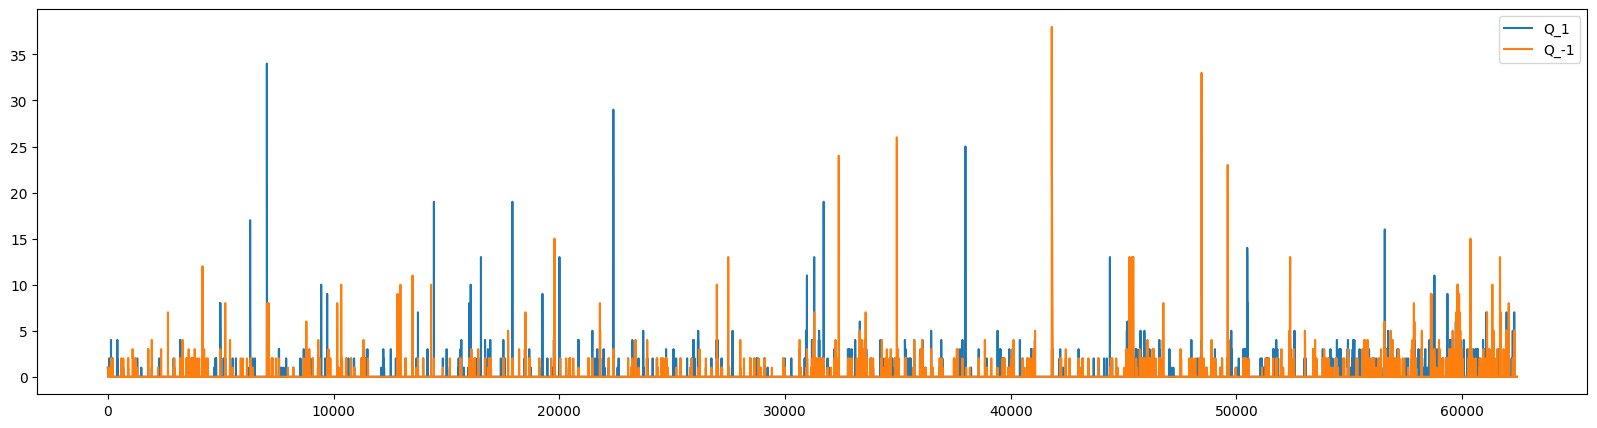

In [6]:
plt.figure(figsize=(20, 5))
for i in range(1,2):
    plt.plot(df_norm[f"Q_{i}"], label=f"Q_{i}")
    plt.plot(df_norm[f"Q_-{i}"], label=f"Q_-{i}")
plt.legend()
plt.show()

### Training DataFrame: ###
From where we will extract our different state vectors $x_k$.

In [7]:
df_train = df_norm.copy()

# 1) event id
event_map = {"L": 0, "C": 1, "M": 2}
df_train["event_id"] = df_train["type"].map(event_map).astype("int64")

# 2) hour
df_train["hour"] = (df_train["time"] // 3600).astype("int64")
hour_map = {h: i for i, h in enumerate(sorted(df_train["hour"].unique()))}
df_train["hour_id"] = df_train["hour"].map(hour_map).astype("int64")

# 3) last event id
df_train["last_event_id"] = df_train["event_id"].shift(1).fillna(0).astype("int64")

# 4) pre-event queues within each constant-pref segment
def _q_event_row(row):
    idx = row.name
    if idx == 0:
        return np.nan 
    prev = df_train.iloc[idx - 1]  # previous row
    l = int(row["lvl"])
    if l == 0:
        return np.nan
    return prev[f"Q_{l}"]
df_train["q_event"] = df_train.apply(_q_event_row, axis=1).astype("float64")

# 5) clean dataframe of nan
df_train = df_train.dropna().reset_index(drop=True)

# 5) keep only what you need
df_train = df_train[["q_event", "hour", "hour_id", "last_event_id", "event_id", "dtk_l"]].copy()
df_train

,q_event,hour,hour_id,last_event_id,event_id,dtk_l
0,0.0,9,0,0,0,0.000000
1,0.0,9,0,0,0,0.000000
2,0.0,9,0,0,0,0.000000
3,1.0,9,0,0,0,0.000000
4,1.0,9,0,0,0,0.000000
...,...,...,...,...,...,...
62419,0.0,15,6,1,2,0.060813
62420,0.0,15,6,2,2,0.000000
62421,0.0,15,6,2,0,0.000000
62422,0.0,15,6,0,2,0.000000


### Training / Target vectors: ###

Vanilla : $x_k = [q_k]$

Hours: $x_k = [q_k, h_k]$

Last Event: $x_k = [q_k, \eta_{k-1}]$

Hours + Last Event: $x_k = [q_k, h_k, \eta_{k-1}]$

In [8]:
from dqrfunctions import build_dataset

data_vanilla = build_dataset(df_train, use_hour=False, use_last_event=False)
data_hour = build_dataset(df_train, use_hour=True, use_last_event=False)
data_last_event = build_dataset(df_train, use_hour=False, use_last_event=True)
data_hour_last_event = build_dataset(df_train, use_hour=True, use_last_event=True)

display(data_hour_last_event)

{'q': tensor([0., 0., 0.,  ..., 0., 0., 0.]),
 'y': tensor([0, 0, 0,  ..., 0, 2, 2]),
 'dt': tensor([0., 0., 0.,  ..., 0., 0., 0.]),
 'last_event': tensor([0, 0, 0,  ..., 2, 0, 2]),
 'hour_id': tensor([0, 0, 0,  ..., 6, 6, 6])}

### Neural Network Definition ###

In [9]:
from dqrfunctions import DQRNet

### Negative Log Likelihood ###

$\text{loss}\left(\theta | \epsilon\right) = l\left(\lambda_\theta | \epsilon\right) = \sum_{i=1}^{B} \left( \Lambda_\theta(x_k)\Delta t_k - \log{\lambda_\theta^{\eta_k}(x_k)} \right)$

In [10]:
from dqrfunctions import dqr_loss

### Training Loop ###

In [11]:
from dqrfunctions import train_model, get_or_train_model

### Vanilla Model ###

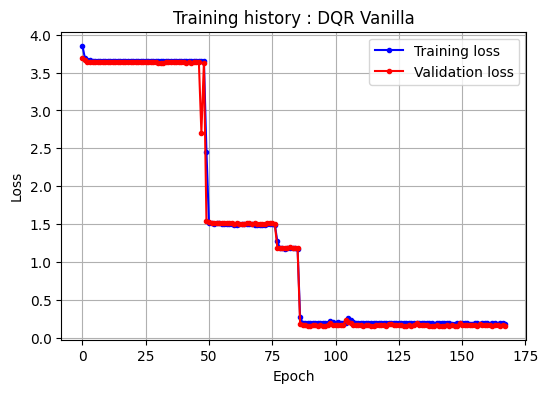

In [ ]:
model_vanilla = get_or_train_model(
    f"models/{ticker}/dqr_vanilla.pt",
    data=data_vanilla,
    compute_model=False,
    use_hour=False,
    use_last_event=False)
model_vanilla.plot_history(model_name="Vanilla")

### Hour Model ###

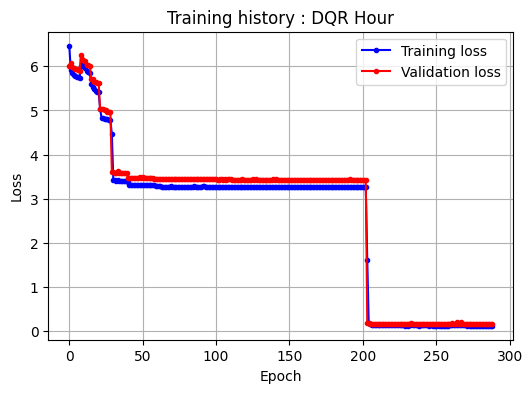

In [ ]:
model_hour = get_or_train_model(
    f"models/{ticker}/dqr_hour.pt",
    data=data_hour,
    compute_model=False,
    use_hour=True,
    use_last_event=False,
    hour_num_classes=df_train["hour_id"].nunique())
model_hour.plot_history(model_name="Hour")

### Last-Event Model ###

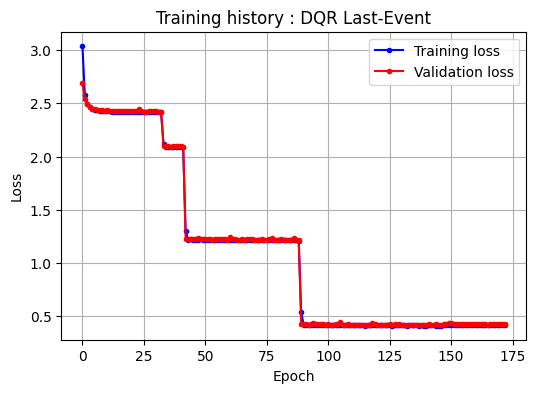

In [ ]:
model_last_event = get_or_train_model(
    f"models/{ticker}/dqr_last_event.pt",
    data=data_last_event,
    compute_model=False,
    use_hour=False,
    use_last_event=True)
model_last_event.plot_history(model_name="Last-Event")

### Hour + Last-Event Model ###

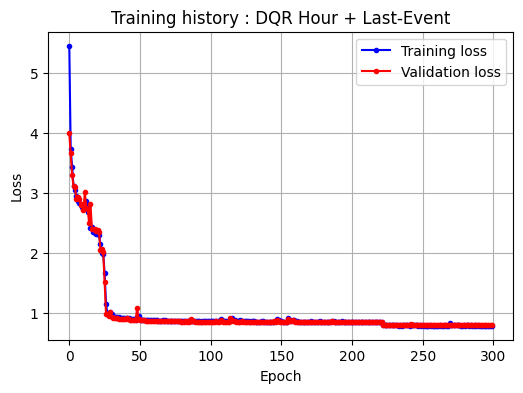

In [ ]:
model_hour_last_event = get_or_train_model(
    f"models/{ticker}/dqr_hour_last_event.pt",
    data=data_hour_last_event,
    compute_model=False,
    use_hour=True,
    use_last_event=True,
    hour_num_classes=df_train["hour_id"].nunique())
model_hour_last_event.plot_history(model_name="Hour + Last-Event")

In [16]:
from dqrfunctions import transition_real, transition_dqr

event_id_np = df_train["event_id"].to_numpy()
last_id_np  = df_train["last_event_id"].to_numpy()
# DQR: last_event_id must match X lines format (torch)
last_id_t = torch.tensor(last_id_np, dtype=torch.long)

T_real = transition_real(event_id_np, last_id_np, n_events=3)
T_dqr = transition_dqr(
                        model=model_last_event,
                        data=data_last_event,
                        last_event_id=last_id_t,
                        n_events=3
)
print(T_real)
print(T_dqr)

[[0.34457336 0.27959079 0.37583586]
 [0.4376132  0.27047696 0.29190984]
 [0.20343537 0.06739261 0.72917203]]
[[0.3599824  0.30541599 0.33460584]
 [0.45389274 0.27533123 0.27075294]
 [0.21030353 0.07977886 0.70987821]]


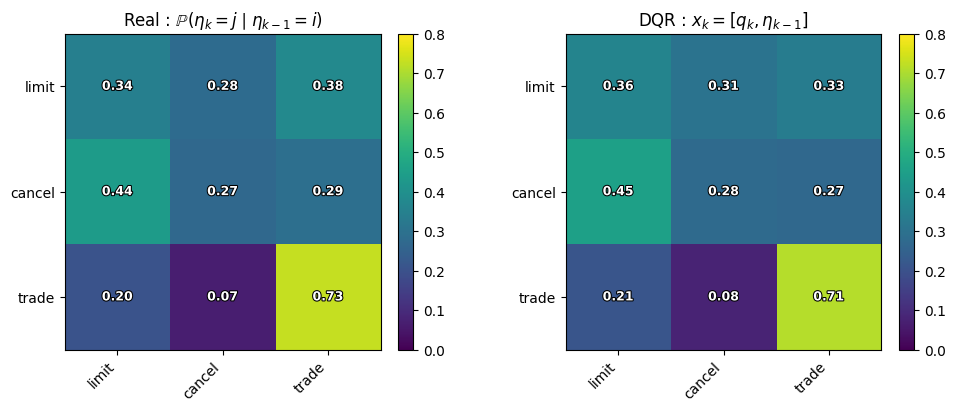

In [17]:
from dqrfunctions import plot_two_heatmaps

EVENT_NAMES = ["limit", "cancel", "trade"]
dqr_last_event_title = r"DQR : $x_k=[q_k,\eta_{k-1}]$"
dqr_hour_last_event_title = r"DQR : $x_k=[q_k,\eta_{k-1},h_k]$"

fig = plot_two_heatmaps(T_real, T_dqr, labels=EVENT_NAMES, dqr_title=dqr_last_event_title)
plt.show()

In [18]:
@torch.no_grad()
def compute_hourly_intensity(model, data, hour_values):
    model.eval()

    # Forward according to model type
    if model.use_hour and model.use_last_event:
        lambdas = model(
            data["q"],
            last_event=data["last_event"],
            hour=data["hour_id"]
        )

    elif model.use_hour:
        lambdas = model(
            data["q"],
            hour=data["hour_id"]
        )

    elif model.use_last_event:
        lambdas = model(
            data["q"],
            last_event=data["last_event"]
        )

    else:
        lambdas = model(data["q"])

    lambdas = lambdas.cpu().numpy()

    df_plot = pd.DataFrame({
        "hour_id": hour_values,
        "lambda_limit": lambdas[:, 0],
        "lambda_cancel": lambdas[:, 1],
        "lambda_trade": lambdas[:, 2]
    })

    hourly = df_plot.groupby("hour_id")["lambda_trade"].mean()

    return hourly

In [19]:
def compute_real_hourly_intensity(df, trade_id=2):
    df_real = df.copy()

    # total observation time per hour
    total_time = df_real.groupby("hour")["dtk_l"].sum()

    # number of trade events per hour
    n_trades = (df_real["event_id"] == trade_id).groupby(df_real["hour"]).sum()

    # empirical intensity = count / total time
    lambda_real = n_trades / total_time

    return lambda_real

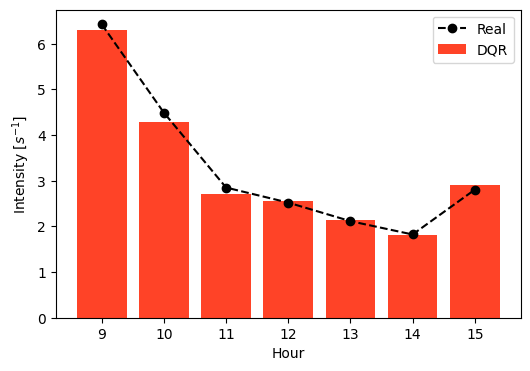

In [ ]:
hourly_dqr_h = compute_hourly_intensity(model_hour, data_hour, df_train["hour"].values)
hourly_dqr_h_le = compute_hourly_intensity(model_hour_last_event, data_hour_last_event, df_train["hour"].values)
hourly_real = compute_real_hourly_intensity(df_train, trade_id=2)

width = 0.35
x = hourly_dqr_h.index.values
fig, ax = plt.subplots(figsize=(6,4))
ax.bar(x - width/2, hourly_dqr_h.values, width=width, color="#FF4327", label="DQR Hour")
ax.bar(x + width/2, hourly_dqr_h_le.values, width=width, color="#2797FF", label="DQR Hour + Last-Event")
ax.plot(x, hourly_real.values, "o--", color="black", label="Real")
ax.set_xlabel("Hour")
ax.set_ylabel(r"Intensity [$s^{-1}$]")
ax.set_xticks(x)
ax.legend()
plt.show()